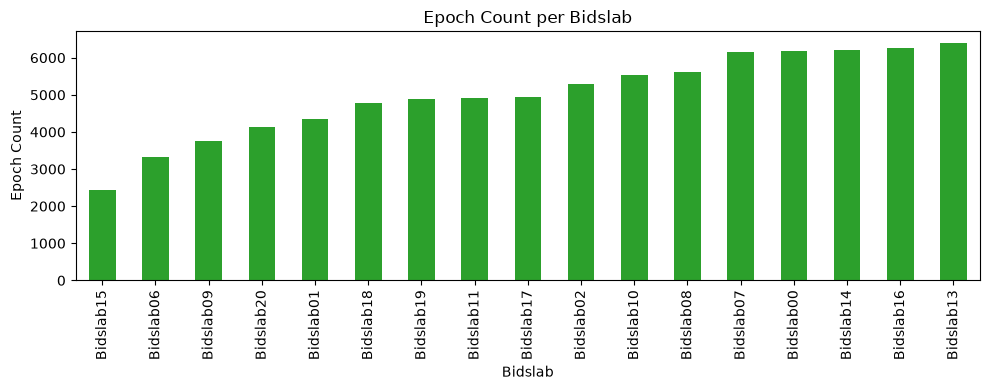

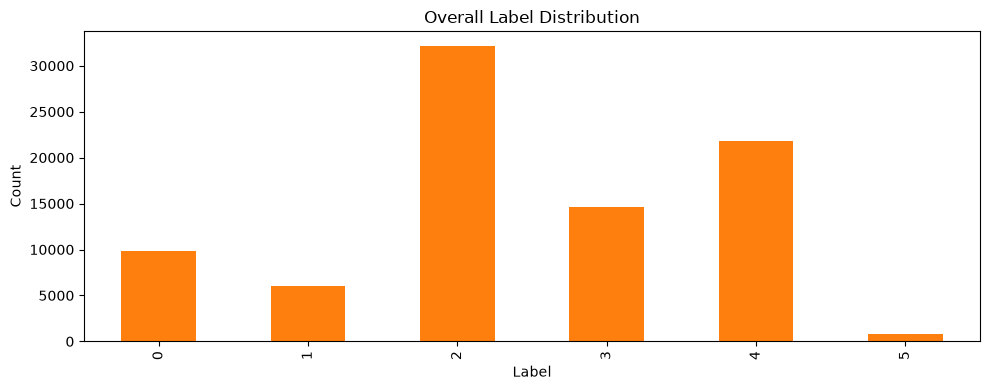

<Figure size 1200x500 with 0 Axes>

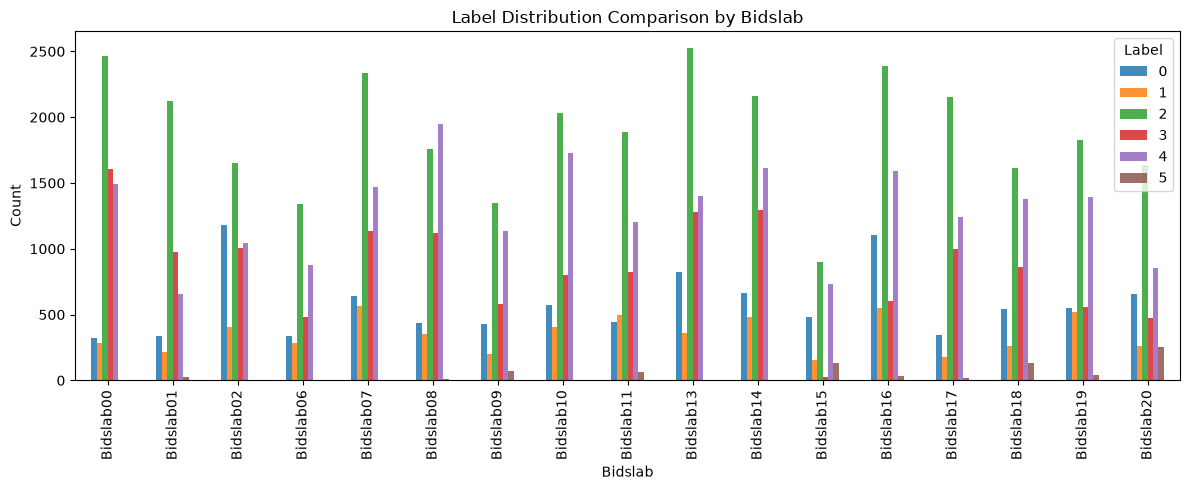

=====================================================Dataset Summary=====================================================
Subjects            : 17
Nights              : 7
Epochs              : 98
Features            : -
Sequence Length     : -

Subject Distribution
Bidslab00       ██████████████████████████████ 7
Bidslab01       █████████████████████ 5
Bidslab02       ██████████████████████████ 6
Bidslab06       █████████████████ 4
Bidslab07       ██████████████████████████████ 7
Bidslab08       ██████████████████████████████ 7
Bidslab09       █████████████████████ 5
Bidslab10       ██████████████████████████ 6
Bidslab11       █████████████████████ 5
Bidslab13       ██████████████████████████████ 7
Bidslab14       ██████████████████████████████ 7
Bidslab15       █████████████ 3
Bidslab16       ██████████████████████████████ 7
Bidslab17       ██████████████████████████ 6
Bidslab18       ██████████████████████████ 6
Bidslab19       ██████████████████████████ 6
Bidslab20       ███████████

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.io as sio


def _find_variable(names):
    for name in names:
        obj = globals().get(name)
        if obj is not None:
            return obj
    return None


def _best_col(df, candidates):
    if df is None:
        return None
    lower_cols = {str(c).lower(): c for c in df.columns}
    for cand in candidates:
        for col_lower, col in lower_cols.items():
            if col_lower == cand.lower() or col_lower.startswith(cand.lower()):
                return col
    return None


def _format_bar(value, max_value, width=20):
    n = int(np.round((value / max_value) * width)) if max_value else 0
    return "█" * max(1, n)


def _find_project_root(start=None):
    start_path = Path(start or Path.cwd()).resolve()
    for candidate in [start_path, start_path.parent]:
        if (candidate / "Dataset" / "raw").exists() or (candidate / "processed").exists():
            return candidate
    return start_path


def _load_raw_bidslab_stats(project_root):
    raw_root = project_root / "Dataset" / "raw"
    if not raw_root.exists():
        return None

    rows = []
    for i in range(69):
        subject_dir = raw_root / f"Bidslab{i:02d}"
        if not subject_dir.is_dir():
            continue

        night_dirs = sorted(
            p for p in subject_dir.iterdir() if p.is_dir() and p.name.isdigit()
        )
        if not night_dirs:
            continue

        for night_dir in night_dirs:
            labels_path = night_dir / "labels.mat"
            if not labels_path.exists():
                continue
            mat = sio.loadmat(labels_path)
            labels = np.asarray(mat["expert_label"]).reshape(-1)
            rows.append({
                "Subject": subject_dir.name,
                "Night": int(night_dir.name),
                "Epochs": int(labels.size),
                "Labels": labels.astype(int),
            })

    if not rows:
        return None

    return pd.DataFrame(rows)


project_root = _find_project_root()
raw_stats_df = _load_raw_bidslab_stats(project_root)

if raw_stats_df is not None and not raw_stats_df.empty:
    df = raw_stats_df[["Subject", "Night", "Epochs"]].copy()
    subjects = df["Subject"].to_numpy()
    night_ids = df["Night"].to_numpy()
    X = None
    y = None
    subject_col = "Subject"
    night_col = "Night"
    stage_col = None
    feature_cols = None
    seq_len = None
else:
    # Fallback to processed metadata if the raw Bidslab folders are unavailable.
    processed_dir = project_root / "processed"
    metadata_path = processed_dir / "metadata.csv"
    x_path = processed_dir / "X.npy"
    y_path = processed_dir / "y.npy"

    if metadata_path.exists():
        df = pd.read_csv(metadata_path)
    else:
        df = None

    if x_path.exists():
        X = np.load(x_path)
    else:
        X = None

    if y_path.exists():
        y = np.load(y_path)
    else:
        y = None

    if df is not None:
        subjects = df["Subject"].to_numpy() if "Subject" in df.columns else None
        night_ids = df["Night"].to_numpy() if "Night" in df.columns else None
    else:
        subjects = None
        night_ids = None

    seq_len = None
    subject_col = _best_col(df, ["subject", "subjek", "id"])
    night_col = _best_col(df, ["night", "session", "recording"])
    stage_col = _best_col(df, ["stage", "sleep_stage", "label", "y", "target"])
    feature_cols = None
    if df is not None:
        if stage_col is not None and subject_col is not None:
            feature_cols = [c for c in df.columns if c not in {stage_col, subject_col, night_col}]
        else:
            feature_cols = df.columns

n_subjects = None
if subjects is not None:
    n_subjects = int(np.unique(subjects).size)
elif df is not None and subject_col is not None:
    n_subjects = int(df[subject_col].nunique())

n_nights = None
if isinstance(night_ids, (list, tuple, np.ndarray, pd.Series)):
    n_nights = int(np.unique(night_ids).size)
elif df is not None and night_col is not None:
    n_nights = int(df[night_col].nunique())

n_epochs = None
if y is not None:
    n_epochs = int(len(y))
elif df is not None:
    n_epochs = int(len(df))
elif X is not None:
    n_epochs = int(X.shape[0])

n_features = None
if X is not None:
    if X.ndim == 3:
        n_features = int(X.shape[2])
    elif X.ndim == 2:
        n_features = int(X.shape[1])
elif feature_cols is not None:
    n_features = int(len(feature_cols))

if seq_len is None and X is not None and X.ndim == 3:
    seq_len = int(X.shape[1])

class_counts = None
if y is not None:
    class_counts = pd.Series(y).value_counts().rename_axis("class").sort_index()
elif df is not None and stage_col is not None:
    class_counts = df[stage_col].value_counts().rename_axis("class").sort_index()

subject_counts = None
if subjects is not None:
    subject_counts = pd.Series(subjects).value_counts().sort_index()
elif df is not None and subject_col is not None:
    subject_counts = df[subject_col].value_counts().sort_index()

subject_summary = None
night_summary = None
label_summary = None

if raw_stats_df is not None and not raw_stats_df.empty:
    subject_summary = (
        raw_stats_df.groupby("Subject")
        .agg(nights=("Night", lambda s: int(pd.Series(s).nunique())), epochs=("Epochs", "sum"))
        .reset_index()
    )

    night_summary = (
        raw_stats_df.groupby(["Subject", "Night"])
        .agg(epochs=("Epochs", "sum"))
        .reset_index()
    )

    label_rows = []
    for _, row in raw_stats_df.iterrows():
        for label in row["Labels"]:
            label_rows.append((row["Subject"], row["Night"], int(label)))

    label_df = pd.DataFrame(label_rows, columns=["Subject", "Night", "label"])
    label_summary = (
        label_df.groupby(["Subject", "Night", "label"])
        .size()
        .reset_index(name="count")
    )

    all_labels = np.concatenate(raw_stats_df["Labels"].tolist())
    overall_label_counts = pd.Series(all_labels).value_counts().sort_index()

    per_subject_label_counts = (
        label_df.groupby(["Subject", "label"])
        .size()
        .unstack(fill_value=0)
    )
    per_subject_label_counts = per_subject_label_counts.reindex(columns=sorted(per_subject_label_counts.columns), fill_value=0)

    plt.figure(figsize=(10, 4))
    subject_summary.set_index("Subject")["epochs"].sort_values().plot(kind="bar", color="tab:green")
    plt.title("Epoch Count per Bidslab")
    plt.xlabel("Bidslab")
    plt.ylabel("Epoch Count")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 4))
    overall_label_counts.plot(kind="bar", color="tab:orange")
    plt.title("Overall Label Distribution")
    plt.xlabel("Label")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 5))
    per_subject_label_counts.plot(kind="bar", figsize=(12, 5), alpha=0.85)
    plt.title("Label Distribution Comparison by Bidslab")
    plt.xlabel("Bidslab")
    plt.ylabel("Count")
    plt.legend(title="Label")
    plt.tight_layout()
    plt.show()

print("=" * 53 + "Dataset Summary" + "=" * 53)
print("Subjects            :", n_subjects if n_subjects is not None else "-")
print("Nights              :", n_nights if n_nights is not None else "-")
print("Epochs              :", n_epochs if n_epochs is not None else "-")
print("Features            :", n_features if n_features is not None else "-")
print("Sequence Length     :", seq_len if seq_len is not None else "-")
if class_counts is not None:
    for cls, cnt in class_counts.items():
        print(f"{str(cls):6} : {int(cnt)}")

if subject_counts is not None:
    print("\nSubject Distribution")
    max_count = subject_counts.max()
    for subject, count in subject_counts.items():
        bar = _format_bar(count, max_count, width=30)
        print(f"{str(subject):15} {bar} {int(count)}")
else:
    print("\nNo subject distribution data found.")

if subject_summary is not None:
    print("\nPer-Bidslab Summary")
    for _, row in subject_summary.sort_values("Subject").iterrows():
        print(f"{row['Subject']}: nights={int(row['nights'])}, epochs={int(row['epochs'])}")

if night_summary is not None:
    print("\nPer-night Summary")
    for subject in sorted(pd.unique(night_summary["Subject"])):
        subject_rows = night_summary[night_summary["Subject"] == subject].sort_values("Night")
        print(f"\n{subject}")
        for _, row in subject_rows.iterrows():
            print(f"  Night {int(row['Night'])}: epochs={int(row['epochs'])}")

if label_summary is not None:
    print("\nPer-night class distribution")
    for subject in sorted(pd.unique(label_summary["Subject"])):
        subject_rows = label_summary[label_summary["Subject"] == subject].sort_values(["Night", "label"])
        print(f"\n{subject}")
        for _, row in subject_rows.iterrows():
            print(f"  Night {int(row['Night'])} | label {int(row['label'])}: {int(row['count'])}")
